<a href="https://colab.research.google.com/github/Shaileshsingh1442007/K-NN/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **second interface **

# 🧠 Sentiment Analysis — VADER & TextBlob
### Interactive NLP Project with Live Widget Interface

This notebook covers:
1. Installation & Setup
2. Text Preprocessing
3. VADER Analysis
4. TextBlob Analysis
5. Combined Pipeline
6. **Interactive Widget Interface**
7. Batch Analysis on Real Dataset
8. Results Visualization

## 📦 Cell 1 — Install **Dependencies**

In [ ]:
# Run this cell first — installs all required libraries
!pip install vaderSentiment textblob nltk pandas matplotlib seaborn ipywidgets
!python -m textblob.download_corpora

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print('✅ All dependencies installed!')

# 📥 Cell 2 — import

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from nltk.corpus import stopwords

print('✅ Imports successful!')

✅ Imports successful!


# **🧹 Cell 3 — Text Preprocessing**

In [ ]:
def preprocess_text(text, remove_stopwords=False):
    """
    Clean and normalize text.
    NOTE: For VADER keep punctuation & casing — they carry sentiment signals.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()       # normalize whitespace

    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        # Keep negations — critical for sentiment!
        negations = {'no', 'not', "n't", 'never', 'neither', 'nor'}
        stop_words -= negations
        text = ' '.join(w for w in text.split() if w not in stop_words)

    return text

# Test it
sample = "  Check out https://example.com — This is NOT bad at all!!  "
print('Original :', repr(sample))
print('Cleaned  :', repr(preprocess_text(sample)))

Original : '  Check out https://example.com — This is NOT bad at all!!  '
Cleaned  : 'check out — this is not bad at all!!'


# ⚡ Cell 4 — VADER Analyzer

In [ ]:
class VADERAnalyzer:
    """
    VADER — Valence Aware Dictionary and sEntiment Reasoner
    Best for: tweets, reviews, short social media text
    Handles: emojis, slang, CAPS, punctuation!!!
    """
    def __init__(self):
        self.analyzer = SentimentIntensityAnalyzer()

    def analyze(self, text):
        scores = self.analyzer.polarity_scores(text)
        compound = scores['compound']

        # Standard VADER thresholds
        if compound >= 0.05:
            label = 'Positive'
        elif compound <= -0.05:
            label = 'Negative'
        else:
            label = 'Neutral'

        return {
            'text': text, 'label': label,
            'compound': round(compound, 4),
            'positive': round(scores['pos'], 4),
            'neutral' : round(scores['neu'], 4),
            'negative': round(scores['neg'], 4),
        }

    def analyze_batch(self, texts):
        return pd.DataFrame([self.analyze(t) for t in texts])


# ── Quick test ──
vader = VADERAnalyzer()
tests = [
    "I LOVE this product!! 😍",
    "The delivery was okay, nothing special.",
    "Absolutely terrible. Never buying again.",
]
for t in tests:
    r = vader.analyze(t)
    print(f"[{r['label']:<8}] compound={r['compound']:+.4f} | {t}")

[Positive] compound=+0.8597 | I LOVE this product!! 😍
[Negative] compound=-0.0920 | The delivery was okay, nothing special.
[Negative] compound=-0.5256 | Absolutely terrible. Never buying again.


# **📝 Cell 5 — TextBlob Analyzer**

In [ ]:
class TextBlobAnalyzer:
    """
    TextBlob — pattern-based NLP library
    Best for: longer text, articles, formal writing
    Extra: subjectivity score (0=objective fact, 1=personal opinion)
    """
    def analyze(self, text):
        blob = TextBlob(text)
        polarity    = blob.sentiment.polarity       # -1 to +1
        subjectivity = blob.sentiment.subjectivity  # 0 to 1

        label = ('Positive' if polarity > 0.1
                 else 'Negative' if polarity < -0.1
                 else 'Neutral')

        subj_label = ('Subjective'  if subjectivity > 0.6
                      else 'Objective' if subjectivity < 0.4
                      else 'Mixed')

        return {
            'text': text, 'label': label,
            'polarity': round(polarity, 4),
            'subjectivity': round(subjectivity, 4),
            'subjectivity_label': subj_label,
        }

    def analyze_batch(self, texts):
        return pd.DataFrame([self.analyze(t) for t in texts])

    def extract_noun_phrases(self, text):
        """Extract key topics/aspects from text."""
        return list(TextBlob(text).noun_phrases)


# ── Quick test ──
tb = TextBlobAnalyzer()
tests = [
    "The camera quality is stunning and photos look professional.",
    "The battery drains very fast and lasts only 4 hours.",
    "The phone was released in Q3 and costs $499.",
]
for t in tests:
    r = tb.analyze(t)
    print(f"[{r['label']:<8}] polarity={r['polarity']:+.4f}  subjectivity={r['subjectivity']:.2f} ({r['subjectivity_label']}) | {t[:55]}")

[Positive] polarity=+0.3000  subjectivity=0.55 (Mixed) | The camera quality is stunning and photos look professi
[Positive] polarity=+0.1300  subjectivity=0.89 (Subjective) | The battery drains very fast and lasts only 4 hours.
[Neutral ] polarity=+0.0000  subjectivity=0.00 (Objective) | The phone was released in Q3 and costs $499.


# **🔀 Cell 6 — Combined Pipeline (Ensemble)**

In [ ]:
class SentimentPipeline:
    """Runs VADER + TextBlob and combines their scores for higher accuracy."""

    def __init__(self):
        self.vader = VADERAnalyzer()
        self.textblob = TextBlobAnalyzer()

    def analyze(self, text, preprocess=True):
        clean = preprocess_text(text) if preprocess else text
        v = self.vader.analyze(clean)
        t = self.textblob.analyze(clean)

        ensemble = round((v['compound'] + t['polarity']) / 2, 4)
        label = ('Positive' if ensemble > 0.05
                 else 'Negative' if ensemble < -0.05
                 else 'Neutral')

        return {
            'text'              : text,
            'vader_label'       : v['label'],
            'vader_compound'    : v['compound'],
            'tb_label'          : t['label'],
            'tb_polarity'       : t['polarity'],
            'tb_subjectivity'   : t['subjectivity'],
            'ensemble_label'    : label,
            'ensemble_score'    : ensemble,
            'models_agree'      : v['label'] == t['label'],
        }

    def analyze_batch(self, texts):
        return pd.DataFrame([self.analyze(t) for t in texts])


pipeline = SentimentPipeline()
print('✅ Pipeline ready!')

✅ Pipeline ready!


# **🎛️ Cell 7 — Interactive Widget Interface**

> Same live interface as the Claude demo — runs inside your notebook!

In [ ]:
import ipywidgets as widgets
from IPython.display import HTML

# ── Colour helpers ──────────────────────────────────────────
COLORS = {
    'Positive': ('#EAF3DE', '#27500A', '😊'),
    'Negative': ('#FCEBEB', '#791F1F', '😞'),
    'Neutral' : ('#F1EFE8', '#444441', '😐'),
}

def make_bar(pct, color):
    return f"""
    <div style='background:#eee;border-radius:6px;height:12px;width:100%;'>
      <div style='background:{color};height:12px;border-radius:6px;
                  width:{pct}%;transition:width 0.4s;'></div>
    </div>"""

def make_chip(word, score):
    if score > 1.5:   bg, fg = '#EAF3DE', '#27500A'
    elif score > 0:   bg, fg = '#C0DD97', '#173404'
    elif score < -1.5:bg, fg = '#FCEBEB', '#791F1F'
    elif score < 0:   bg, fg = '#F7C1C1', '#501313'
    else:             bg, fg = '#F1EFE8', '#888780'
    tip = f'score: {score}' if score != 0 else 'neutral'
    return (f"<span title='{tip}' style='display:inline-block;padding:3px 10px;"
            f"border-radius:6px;background:{bg};color:{fg};"
            f"font-size:13px;margin:3px;'>{word}</span>")

# ── Lightweight lexicon for word-level highlighting ─────────
LEXICON = {
    'amazing':3,'excellent':3,'outstanding':3,'fantastic':3,'wonderful':3,
    'great':2,'good':2,'love':2,'happy':2,'pleased':2,'enjoy':2,'awesome':2,
    'nice':1,'okay':0.5,'fine':0.5,'decent':0.5,
    'bad':-2,'terrible':-3,'awful':-3,'horrible':-3,'worst':-3,'hate':-3,
    'poor':-2,'disappointing':-2,'frustrated':-2,'useless':-2,
    'slow':-1,'late':-1,'problem':-1,'issue':-1,
    'not':-1,'never':-1.5,'no':-1,
}

def run_widget(text, model_choice):
    """Core analysis function called by the widget."""
    if not text.strip():
        return

    # ── Choose model ────
    if model_choice == 'VADER':
        r = vader.analyze(text)
        label, score = r['label'], r['compound']
        pos_pct = int(r['positive'] * 100)
        neg_pct = int(r['negative'] * 100)
        neu_pct = 100 - pos_pct - neg_pct
        extra_html = f"""
        <tr><td style='color:#888;padding:4px 8px;'>VADER Compound</td>
            <td style='padding:4px 8px;font-weight:500;'>{score:+.4f}</td></tr>"""

    elif model_choice == 'TextBlob':
        r = tb.analyze(text)
        label, score = r['label'], r['polarity']
        pos_pct = max(0, int(score * 100))
        neg_pct = max(0, int(-score * 100))
        neu_pct = 100 - pos_pct - neg_pct
        extra_html = f"""
        <tr><td style='color:#888;padding:4px 8px;'>Polarity</td>
            <td style='padding:4px 8px;font-weight:500;'>{score:+.4f}</td></tr>
        <tr><td style='color:#888;padding:4px 8px;'>Subjectivity</td>
            <td style='padding:4px 8px;font-weight:500;'>
              {r['subjectivity']:.2f} ({r['subjectivity_label']})</td></tr>"""

    else:  # Ensemble
        r = pipeline.analyze(text)
        label, score = r['ensemble_label'], r['ensemble_score']
        pos_pct = max(0, int(score * 100))
        neg_pct = max(0, int(-score * 100))
        neu_pct = 100 - pos_pct - neg_pct
        agree = '✅ Yes' if r['models_agree'] else '⚠️ No'
        extra_html = f"""
        <tr><td style='color:#888;padding:4px 8px;'>VADER</td>
            <td style='padding:4px 8px;font-weight:500;'>{r['vader_label']} ({r['vader_compound']:+.4f})</td></tr>
        <tr><td style='color:#888;padding:4px 8px;'>TextBlob</td>
            <td style='padding:4px 8px;font-weight:500;'>{r['tb_label']} ({r['tb_polarity']:+.4f})</td></tr>
        <tr><td style='color:#888;padding:4px 8px;'>Models agree?</td>
            <td style='padding:4px 8px;font-weight:500;'>{agree}</td></tr>"""

    bg, fg, emoji = COLORS[label]
    conf = max(pos_pct, neg_pct, neu_pct)
    conf_lbl = 'High' if conf > 65 else 'Medium' if conf > 45 else 'Low'

    # Word-level chips
    tokens = re.sub(r'[^a-z\s]', '', text.lower()).split()
    chips = ''.join(make_chip(w, LEXICON.get(w, 0)) for w in tokens if len(w) > 1)
    pos_words = sum(1 for w in tokens if LEXICON.get(w, 0) > 0)
    neg_words = sum(1 for w in tokens if LEXICON.get(w, 0) < 0)

    html = f"""
    <div style='font-family:sans-serif;max-width:680px;padding:16px;
                border:1px solid #ddd;border-radius:12px;background:#fff;'>

      <!-- Header -->
      <div style='display:flex;align-items:center;gap:14px;margin-bottom:16px;'>
        <span style='font-size:36px;'>{emoji}</span>
        <div style='flex:1;'>
          <div style='font-size:22px;font-weight:600;color:#111;'>{label}</div>
          <div style='font-size:13px;color:#888;'>Confidence: {conf_lbl} ({conf}%)</div>
        </div>
        <span style='padding:4px 14px;border-radius:20px;
                     background:{bg};color:{fg};
                     font-size:13px;font-weight:600;'>{label.upper()}</span>
      </div>

      <!-- Bars -->
      <div style='margin-bottom:16px;'>
        <div style='display:flex;align-items:center;gap:10px;margin:6px 0;'>
          <span style='width:70px;font-size:13px;color:#666;'>Positive</span>
          {make_bar(pos_pct, '#639922')}
          <span style='width:36px;font-size:13px;font-weight:500;text-align:right;'>{pos_pct}%</span>
        </div>
        <div style='display:flex;align-items:center;gap:10px;margin:6px 0;'>
          <span style='width:70px;font-size:13px;color:#666;'>Neutral</span>
          {make_bar(neu_pct, '#888780')}
          <span style='width:36px;font-size:13px;font-weight:500;text-align:right;'>{neu_pct}%</span>
        </div>
        <div style='display:flex;align-items:center;gap:10px;margin:6px 0;'>
          <span style='width:70px;font-size:13px;color:#666;'>Negative</span>
          {make_bar(neg_pct, '#E24B4A')}
          <span style='width:36px;font-size:13px;font-weight:500;text-align:right;'>{neg_pct}%</span>
        </div>
      </div>

      <!-- Word chips -->
      <div style='margin-bottom:16px;'>
        <div style='font-size:13px;color:#888;margin-bottom:6px;font-weight:500;'>Word-level analysis:</div>
        <div>{chips}</div>
      </div>

      <!-- Stats grid -->
      <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin-bottom:16px;'>
        {''.join(f"<div style='background:#f5f5f3;border-radius:8px;padding:10px;text-align:center;'><div style='font-size:20px;font-weight:600;'>{v}</div><div style='font-size:11px;color:#888;margin-top:2px;'>{l}</div></div>" for v,l in [(len(tokens),'words'),(pos_words,'positive'),(neg_words,'negative'),(f'{score:+.2f}','score')])}
      </div>

      <!-- Model details -->
      <div style='border-top:1px solid #eee;padding-top:12px;'>
        <div style='font-size:13px;color:#888;font-weight:500;margin-bottom:6px;'>Model details:</div>
        <table style='font-size:13px;width:100%;'>{extra_html}</table>
      </div>
    </div>"""

    display(HTML(html))


# ── Build widgets ───────────────────────────────────────────
text_input = widgets.Textarea(
    value='I absolutely love this product! It exceeded all my expectations!',
    placeholder='Type your text here...',
    layout=widgets.Layout(width='680px', height='80px')
)

model_select = widgets.ToggleButtons(
    options=['VADER', 'TextBlob', 'Ensemble'],
    value='VADER',
    description='Model:',
    button_style='info',
)

examples = [
    ('😊 Positive', 'The product is absolutely amazing and exceeded all my expectations!'),
    ('😞 Negative', 'This is the worst experience I have ever had. Totally disappointed.'),
    ('😐 Neutral',  'The delivery arrived on Tuesday. It was a standard package.'),
    ('🤔 Mixed',    'The camera is great but the battery life is absolutely terrible.'),
    ('😄 Excited',  'AMAZING service!! The staff were SO friendly and helpful!!!'),
]

example_buttons = [widgets.Button(description=label,
                                   layout=widgets.Layout(width='auto'),
                                   button_style='') for label, _ in examples]

for btn, (_, txt) in zip(example_buttons, examples):
    def make_handler(t):
        def handler(b):
            text_input.value = t
            out.clear_output()
            with out:
                run_widget(text_input.value, model_select.value)
        return handler
    btn.on_click(make_handler(txt))

analyze_btn = widgets.Button(
    description='Analyze ▶',
    button_style='success',
    layout=widgets.Layout(width='150px', height='36px')
)
out = widgets.Output()

def on_analyze(b):
    out.clear_output()
    with out:
        run_widget(text_input.value, model_select.value)

analyze_btn.on_click(on_analyze)

# ── Layout ──────────────────────────────────────────────────
display(HTML("<h3 style='font-family:sans-serif;'>🎛️ Interactive Sentiment Analyzer</h3>"))
display(HTML("<p style='font-family:sans-serif;font-size:13px;color:#666;'>Try an example:</p>"))
display(widgets.HBox(example_buttons))
display(HTML("<br>"))
display(model_select)
display(text_input)
display(analyze_btn)
display(out)

# Run once on load
with out:
    run_widget(text_input.value, model_select.value)

ToggleButtons(button_style='info', description='Model:', options=('VADER', 'TextBlob', 'Ensemble'), value='VAD…

Textarea(value='I absolutely love this product! It exceeded all my expectations!', layout=Layout(height='80px'…

Button(button_style='success', description='Analyze ▶', layout=Layout(height='36px', width='150px'), style=But…

Output()

# **📊 Cell 8 — Batch Analysis on Sample Dataset**

In [ ]:
# Sample real-world style reviews
reviews = [
    "Absolutely fantastic product! Shipped fast and works perfectly.",
    "Terrible quality. Broke after 2 days. Waste of money.",
    "It's okay. Does the job but nothing special.",
    "BEST PURCHASE EVER!! I'm so happy with this!!",
    "Not bad, but could be better. The packaging was damaged.",
    "Excellent customer service and quick delivery. Highly recommend!",
    "Disappointed. The product looks nothing like the photos.",
    "Average product, average price. No complaints.",
    "This has completely changed my life. Truly amazing!",
    "Do NOT buy this. Horrible experience from start to finish.",
]

df = pipeline.analyze_batch(reviews)
display_cols = ['text', 'vader_label', 'vader_compound',
                'tb_label', 'tb_polarity', 'tb_subjectivity',
                'ensemble_label', 'models_agree']
df_display = df[display_cols].copy()
df_display['text'] = df_display['text'].str[:55] + '...'

print(f'Total reviews: {len(df)}')
print(f'Positive     : {(df.ensemble_label=="Positive").sum()}')
print(f'Negative     : {(df.ensemble_label=="Negative").sum()}')
print(f'Neutral      : {(df.ensemble_label=="Neutral").sum()}')
print(f'Models agree : {df.models_agree.sum()}/{len(df)}\n')
df_display

Total reviews: 10
Positive     : 6
Negative     : 3
Neutral      : 1
Models agree : 8/10



,text,vader_label,vader_compound,tb_label,tb_polarity,tb_subjectivity,ensemble_label,models_agree
0,Absolutely fantastic product! Shipped fast and...,Positive,0.8550,Positive,0.5667,0.8333,Positive,True
1,Terrible quality. Broke after 2 days. Waste of...,Negative,-0.8271,Negative,-0.6000,0.5000,Negative,True
2,It's okay. Does the job but nothing special....,Negative,-0.3479,Positive,0.4286,0.5357,Neutral,False
3,BEST PURCHASE EVER!! I'm so happy with this!!...,Positive,0.9024,Positive,1.0000,0.6500,Positive,True
4,"Not bad, but could be better. The packaging wa...",Positive,0.2323,Positive,0.4250,0.5833,Positive,True
5,Excellent customer service and quick delivery....,Positive,0.7773,Positive,0.5111,0.6800,Positive,True
6,Disappointed. The product looks nothing like t...,Negative,-0.6381,Negative,-0.7500,0.7500,Negative,True
7,"Average product, average price. No complaints....",Positive,0.3089,Negative,-0.1500,0.4000,Positive,False
8,This has completely changed my life. Truly ama...,Positive,0.7901,Positive,0.4250,0.6500,Positive,True
9,Do NOT buy this. Horrible experience from star...,Negative,-0.6280,Negative,-1.0000,1.0000,Negative,True


# **📈 Cell 9 — Visualizations**

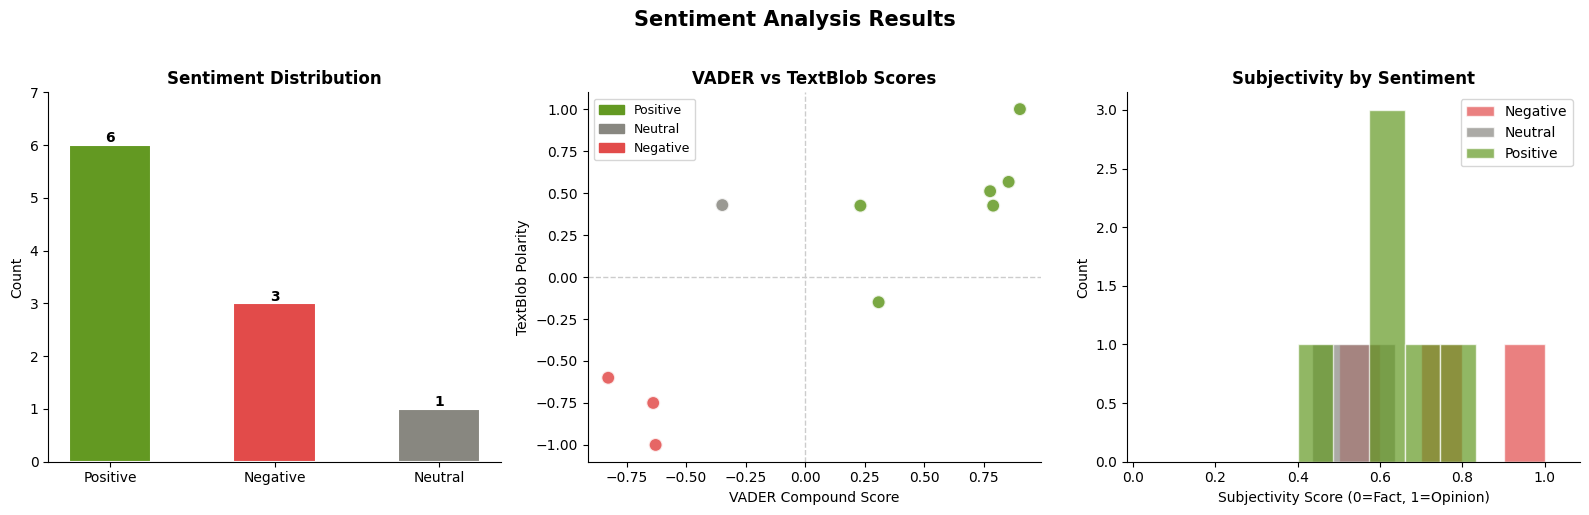

Plot saved as sentiment_plots.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Analysis Results', fontsize=15, fontweight='bold', y=1.02)

colors_map = {'Positive': '#639922', 'Neutral': '#888780', 'Negative': '#E24B4A'}

# ── Plot 1: Ensemble label distribution ─────────────────────
counts = df['ensemble_label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors_map[l] for l in counts.index],
            edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Sentiment Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts.values) + 1)
axes[0].spines[['top','right']].set_visible(False)

# ── Plot 2: VADER compound vs TextBlob polarity scatter ─────
label_colors = [colors_map[l] for l in df['ensemble_label']]
scatter = axes[1].scatter(df['vader_compound'], df['tb_polarity'],
                           c=label_colors, s=100, edgecolors='white',
                           linewidth=1.5, alpha=0.85)
axes[1].axhline(0, color='#ccc', linewidth=1, linestyle='--')
axes[1].axvline(0, color='#ccc', linewidth=1, linestyle='--')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('TextBlob Polarity')
axes[1].set_title('VADER vs TextBlob Scores', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
patches = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
axes[1].legend(handles=patches, fontsize=9)

# ── Plot 3: Subjectivity distribution ───────────────────────
for label, grp in df.groupby('ensemble_label'):
    axes[2].hist(grp['tb_subjectivity'], bins=5, alpha=0.7,
                 label=label, color=colors_map[label], edgecolor='white')
axes[2].set_xlabel('Subjectivity Score (0=Fact, 1=Opinion)')
axes[2].set_ylabel('Count')
axes[2].set_title('Subjectivity by Sentiment', fontweight='bold')
axes[2].legend()
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('sentiment_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as sentiment_plots.png')

# **🔍 Cell 10 — Aspect-Based Sentiment**

In [ ]:
def aspect_sentiment(text, aspects):
    """
    Analyze sentiment for specific aspects within a review.
    Useful for product reviews: camera, battery, price, etc.
    """
    sentences = re.split(r'[.!?]', text)
    results = {}
    for aspect in aspects:
        relevant = [s for s in sentences if aspect.lower() in s.lower()]
        if relevant:
            combined = ' '.join(relevant)
            r = vader.analyze(combined)
            results[aspect] = {
                'label': r['label'],
                'score': r['compound'],
                'context': combined.strip()[:80]
            }
        else:
            results[aspect] = {'label': 'Not mentioned', 'score': 0, 'context': '-'}
    return results


review = (
    "The camera quality is absolutely stunning and takes brilliant photos. "
    "However, the battery drains very fast and lasts only 4 hours. "
    "The screen is vibrant and beautiful. "
    "The price is way too high for what you actually get."
)

aspects = ['camera', 'battery', 'screen', 'price']
results = aspect_sentiment(review, aspects)

print(f'Review: {review[:80]}...\n')
print(f'{"Aspect":<12} {"Label":<12} {"Score":>8}   Context')
print('-' * 75)
for asp, data in results.items():
    emoji = '😊' if data['label']=='Positive' else '😞' if data['label']=='Negative' else '😐'
    print(f"{asp:<12} {emoji} {data['label']:<10} {data['score']:>+.4f}   {data['context']}")

Review: The camera quality is absolutely stunning and takes brilliant photos. However, t...

Aspect       Label           Score   Context
---------------------------------------------------------------------------
camera       😊 Positive   +0.7713   The camera quality is absolutely stunning and takes brilliant photos
battery      😐 Neutral    +0.0000   However, the battery drains very fast and lasts only 4 hours
screen       😊 Positive   +0.8074   The screen is vibrant and beautiful
price        😐 Neutral    +0.0000   The price is way too high for what you actually get


# **💾 Cell 11 — Export Results to CSV**

In [ ]:
df.to_csv('sentiment_results.csv', index=False)
print('✅ Results saved to sentiment_results.csv')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Columns: {list(df.columns)}')

NameError: name 'df' is not defined